# Simulate populations with spontaneus creation
## Part 6

### Calculate Population Recursively

We want to know the population $P$ at the current time step $p$. If we know the population at the end of the previous time step, $P_{p-1}$, then the population that will survive the current time step is $P_{p-1}(1-D)$ where $D$ is the chance of death. The population increases by $B$ protocells each period (we will assume it always survives the first period). The full recursive function is then as follows:

$$P_p=P_{p-1}(1-D)+B$$

Note that this equation requires feeding in the value of the previous iteration $P_{p-1}$, making this a recursive function.

Let's see the function on a graph.

In [2]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
import random

In [27]:
# Set simulation parameters
birth_rate = 1
death_chance = 0.1
n_periods = 100

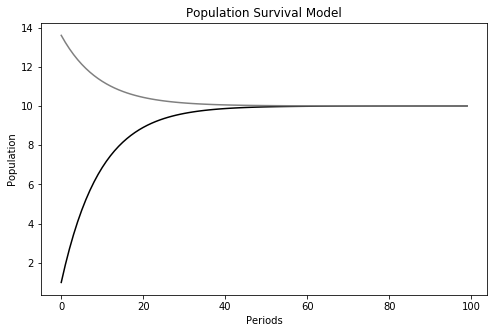

In [34]:
''' Recursive function for popualtion growth with contstant birth rate and death chance'''
def recursive_population(n_periods, death_chance, pop):
    p_function = []
    for i in range(0,n_periods):
        pop = pop*(1-death_chance)+1
        p_function.append(pop)
    return p_function

# TODO: plot lines from 0 to 15 with gradient color black to light grey
p_function_0 = recursive_population(n_periods, death_chance, 0)
p_function_14 = recursive_population(n_periods, death_chance, 14)

fig, ax = plt.subplots(figsize=(8,5))
ax.set(
    title=f"Population Survival Model",
    xlabel="Periods",
    ylabel="Population",
)
ax.plot(range(0, n_periods), p_function_0, color='k')
ax.plot(range(0, n_periods), p_function_14, color='grey')
plt.show()

As you can see, when the starting population is below 10, the population increases towards 10 and then levels off, never surpassing 10. Similarily, when the starting population is above 10, the population decreases until it reaches 10 and then stabilizes.

Let's see how this model compares to the simulation (The simulation below is taken from part 2, we only add a line to show population growth from 0 based on our model):

In [35]:
def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""

    return random.random() <= chance


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self


class environment():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, birth_rate, death_chance):
        self.birth_rate = birth_rate
        self.death_chance = death_chance
        self.population = []
        self.history =[]

    def __call__(self):
        self.population = [e() for e in self.population if not trial(self.death_chance)]
        self.population.append(entity())
        self.history.append(len(self.population))

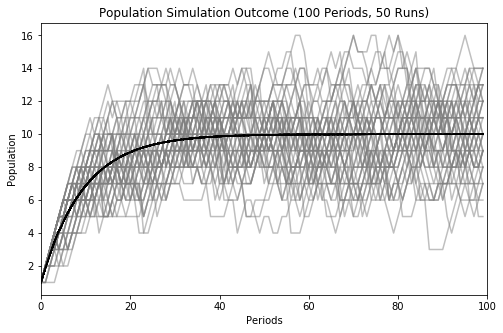

In [36]:
def run_sim(birth_rate, death_chance, n_periods, r_runs):
    """ Run simulation of environment for n periods and repeat r times, then plot the result"""

    # Set up plot
    fig, ax = plt.subplots(figsize=(8,5))
    ax.set(
        title=f"Population Simulation Outcome ({n_periods} Periods, {r_runs} Runs)",
        xlabel="Periods",
        ylabel="Population",
        xlim=(0, n_periods)
    )

    # Run simulation n times with r repeats.
    for r in range(r_runs):
        env = environment(birth_rate, death_chance)
        for period in range(0, n_periods):
            env()
        ax.plot(env.history, color=[.5, .5, .5, .5])
        ax.plot(range(0, n_periods), p_function, color='k')

# Run the simulation
run_sim(1, .1, 100, 50)

### Conclusion

The model matches perfectly and shows the expected population at each time step.